### [K線捕手](https://www.facebook.com/kevinyang20180801)  

[台股下跌129點 生技火紅 資服股互見漲跌停](https://www.ctee.com.tw/news/20250417701105-430201?fbclid=IwY2xjawJuivZleHRuA2FlbQIxMQABHvjaj9LV3uxd_jyYzTxU8Uonj5Guks3UXVj9ayei28q04aMJtnRTzVDsZN40_aem_iloRXgl51J6i-2UpzWm2_Q)  
  
[台積法說前 內外資齊喊買 大摩呼籲客戶把握「這件事」](https://www.ctee.com.tw/news/20250417700061-430201?fbclid=IwY2xjawJuiw1leHRuA2FlbQIxMQABHkXeibhakYmtoOB066rctir4HJBKZ9xIWlh4feXQ1aNpq_Uz6cm8X0O7r0Pb_aem_6wm8ifqQ0GhamVsKjlQjBQ)  
  
[「百年零息債」傳聞四起！美債動盪波及上市櫃公司 遭殃名單曝光](https://www.ctee.com.tw/news/20250417700097-430201?fbclid=IwY2xjawJuiytleHRuA2FlbQIxMQABHq8o6n7HFCUzuwD1lguqmJ8yrrr41VYklRY1i1rIAh1MVvZujpfvSeXx6ABI_aem_iP0_rFaZqrpSxorfotV7tg)  
  
[Fed 主席鮑爾放鷹 優先防範通膨 粉碎市場降息救市期待](https://money.udn.com/money/story/10511/8682160?fbclid=IwY2xjawJui0FleHRuA2FlbQIxMQABHtqbXeTB51hInANs-6EBkUaDUG7QHq9yG6XlDufI1KtySSL6C-CdJWwHbNjJ_aem_2ORjuJUsUI867pYbAFUIIA)  
  
[金價飆 銀樓牌價衝13,650元 臺銀黃金存摺站上新天價](https://money.udn.com/money/story/5613/8682163?fbclid=IwY2xjawJui1hleHRuA2FlbQIxMQABHuaim0bsW9kBFsKeM1V1pM2DzdshrSc9oUauTUj0NRC4y3usuQrlkFm6Wl1V_aem_dSAjHgztZP7oNnQdtHkiEg)  
  
[美股復活節前受壓！道瓊挫逾500點](https://tw.news.yahoo.com/%E7%BE%8E%E8%82%A1%E5%BE%A9%E6%B4%BB%E7%AF%80%E5%89%8D%E5%8F%97%E5%A3%93-%E9%81%93%E7%93%8A%E6%8C%AB%E9%80%BE500%E9%BB%9E-220014300.html)  
  
[台股盤前要聞〉台積電2奈米以下美廠占3成、 中鼎美國踩雷196億、國巨股票擬1拆4](https://m.cnyes.com/news/id/5943286?utm_source=App&utm_medium=android&utm_campaign=5943286)  

期貨開平盤，反彈後的短線盤整。  
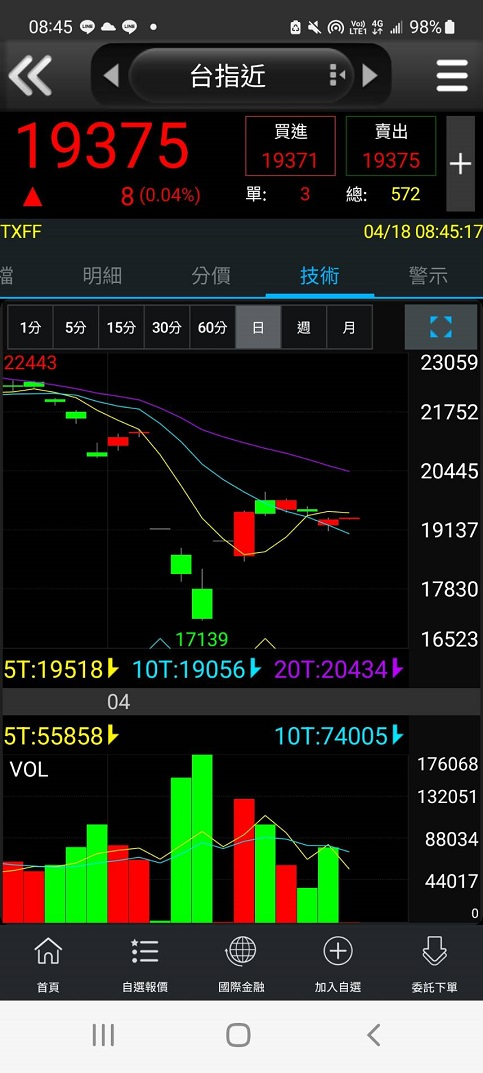  
  
加權指數和櫃買指數也是在平盤附近。  
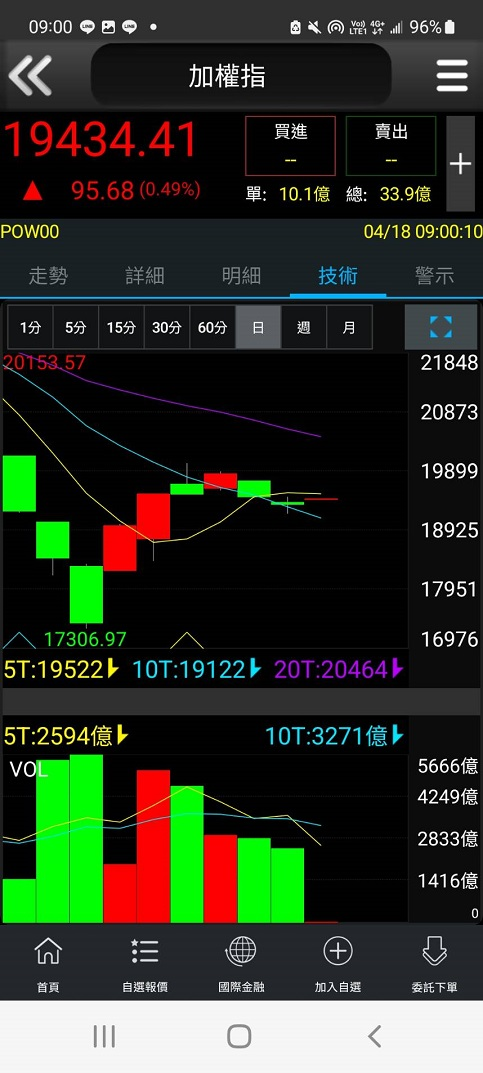  
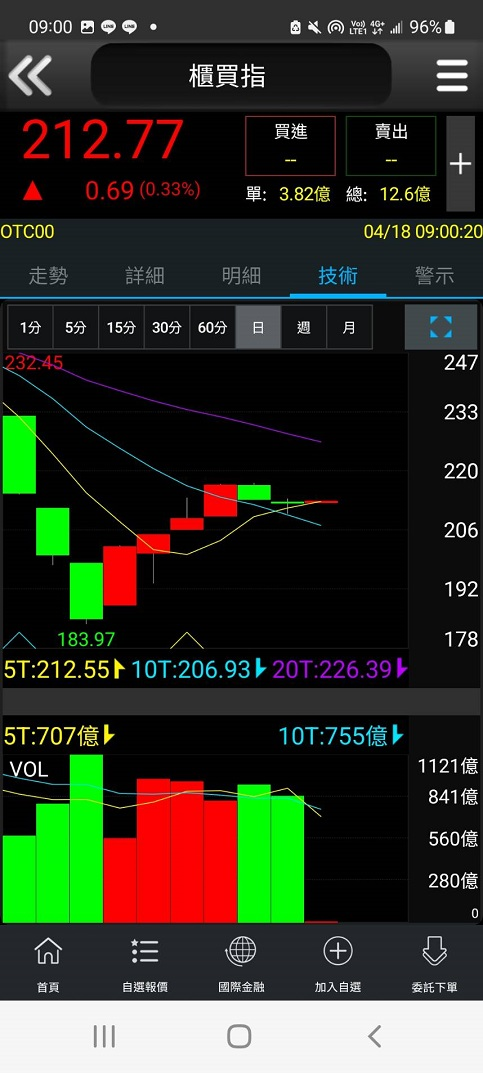  
  
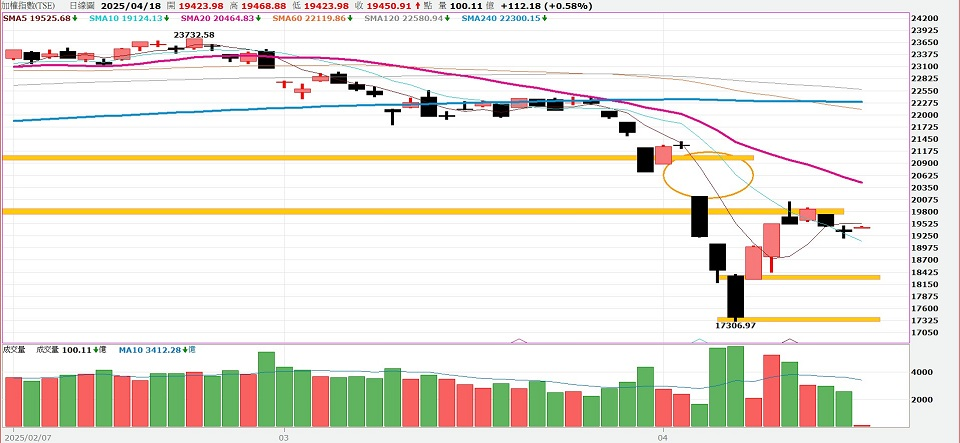  
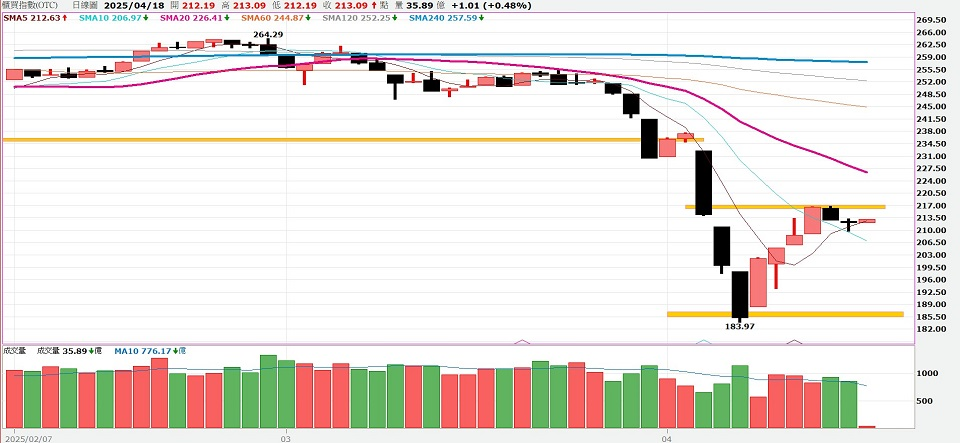  
  
臺幣升值趨緩。  
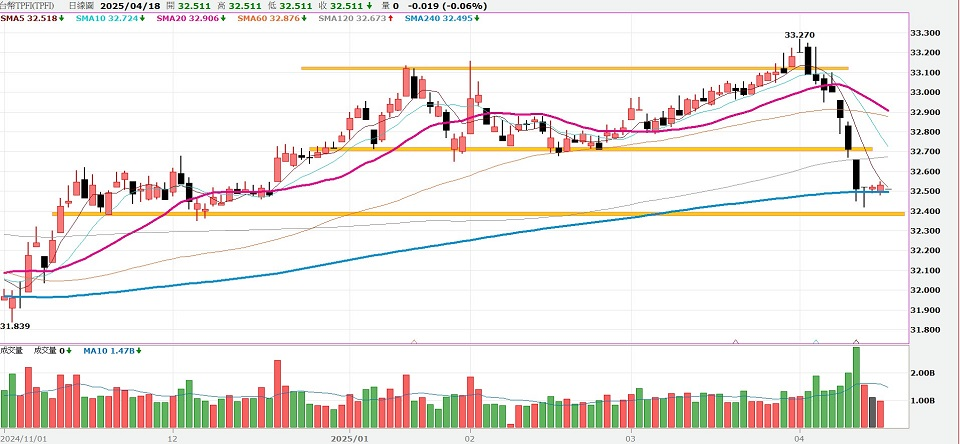  
  
加權指數貢獻排行：  
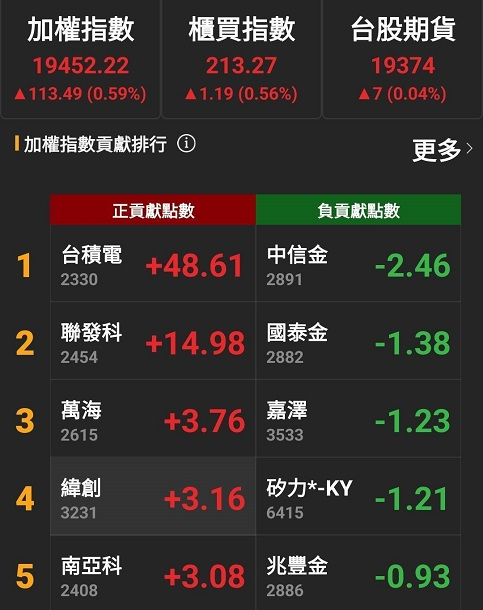  

金耘國際(4950)  
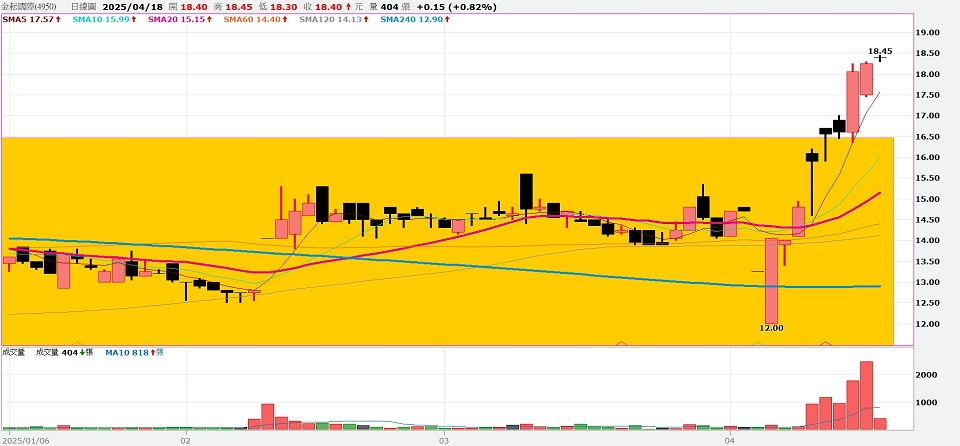  
  
八方雲集(2753)  
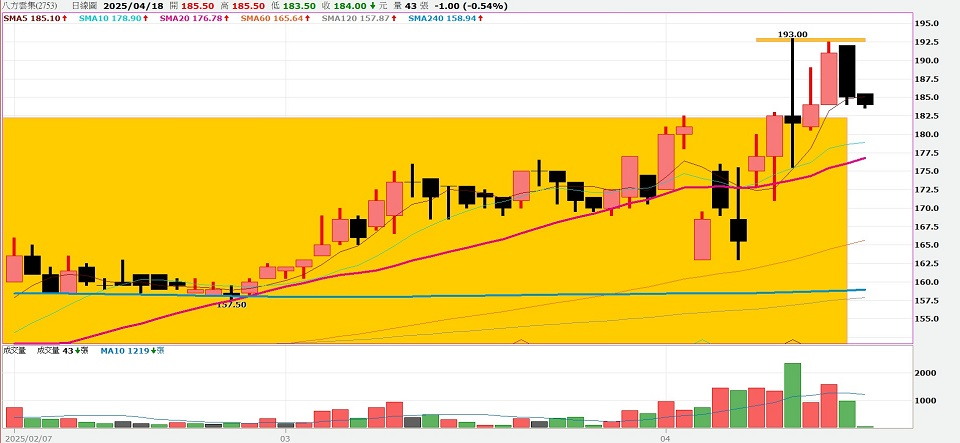  
  
陞泰(8072)  
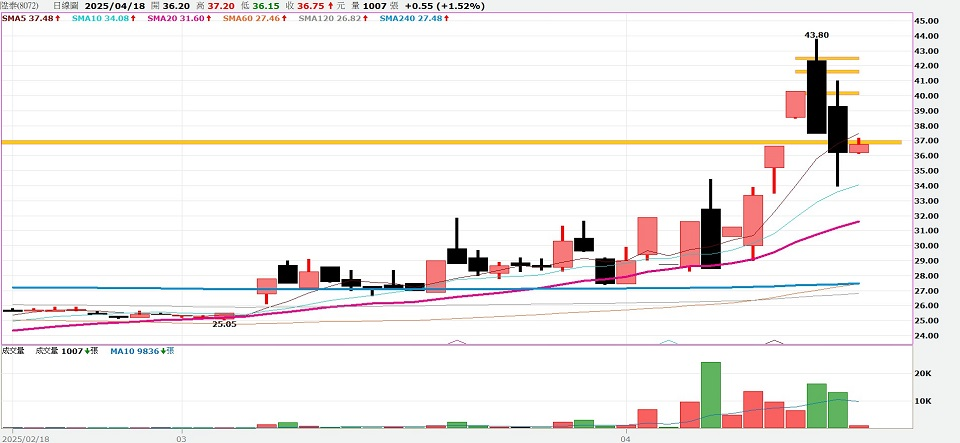  

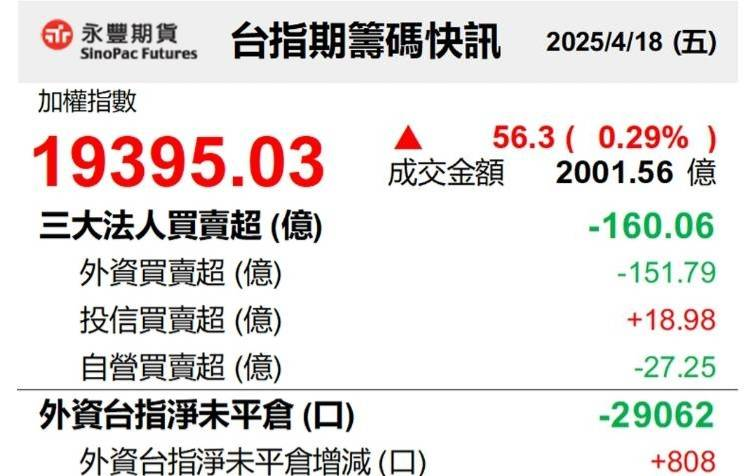  
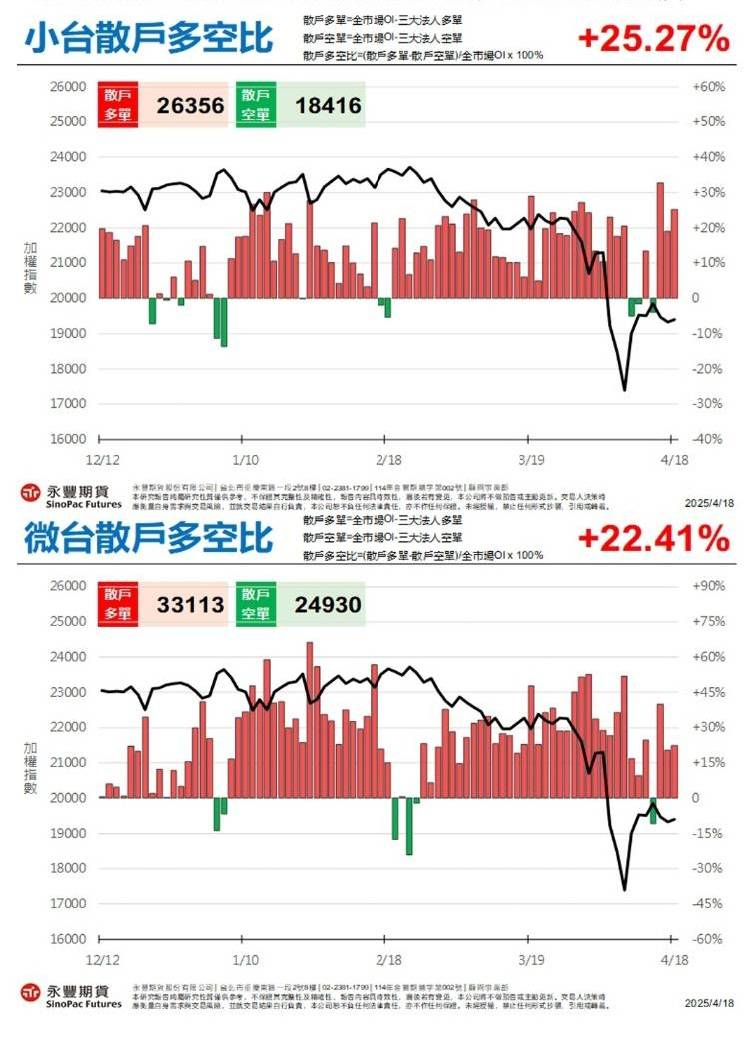  

### 本日進度  
* 量化技術分析系統  
  - 調整資料庫結構：  
    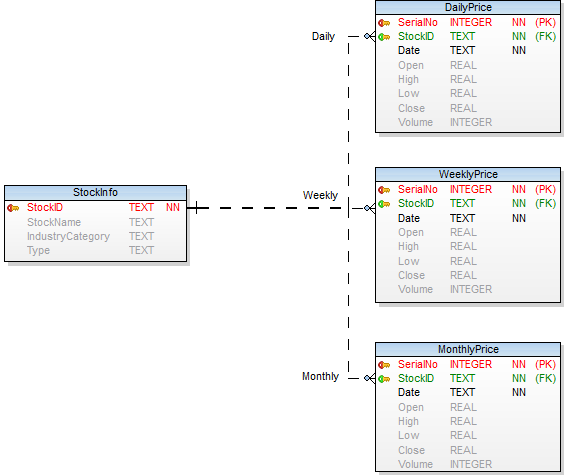  
* 驗證：StockChartPatterns類別  

In [1]:
import os
import sys
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import mplfinance as mpf
import numpy as np
import myutils

In [2]:
def date_to_index(df_in,date_in) :
    number_array = df_in.index == date_in
    idx = 0
    for number_index in number_array :
        if number_index == True :
            break
        idx = idx + 1
    return idx

In [3]:
# 型態視覺化：型態後處理程序之雛形
def patterns_visualization(prices,patterns) :
    for pattern_name in patterns:
        # 顯示型態名稱
        print('＃＃＃ {} ＃＃＃'.format(pattern_name))
        for pattern in patterns[pattern_name] :
            
            # 顯示型態轉折點參數
            print('☆ 轉折點參數 ＝ {} \n★ 型態資訊 ＝ \n {} '.format(pattern['argument'],pattern['window']))
            
            # 視覺化型態
            pattern_window = pattern['window']
            
            # 驗證：型態最後一個轉折點離價格資料距離
            print('◆ 型態最後一個轉折點離價格資料距離 ＝ {} '.format( date_to_index(prices,prices.iloc[-1].name) - date_to_index(prices,pattern_window.iloc[-1]['Date']) ))
            
            seq_of_seq_of_points = []
            if pattern_name == '雙重頂' or pattern_name == '雙重底':
                pattern_first_date_idx  = pattern_window.iloc[0].name
                pattern_start_date_idx  = pattern_window.iloc[1].name
                neckline_start_date_idx = pattern_start_date_idx - ((pattern_start_date_idx - pattern_first_date_idx) // 2) 
                neckline_end_date_idx   = ((pattern_start_date_idx - pattern_first_date_idx) // 2) + pattern_window.iloc[-1].name
                neckline_end_date_idx   = neckline_end_date_idx if neckline_end_date_idx < prices.shape[0] else pattern_window.iloc[-1].name
            
                neckline_start_date  = prices.iloc[neckline_start_date_idx].name.strftime("%Y-%m-%d")
                neckline_end_date    = prices.iloc[neckline_end_date_idx].name.strftime("%Y-%m-%d")
                neckline_start_price = pattern_window.iloc[2]['Price']
                neckline_end_price   = pattern_window.iloc[2]['Price']
        
                # 設定頸線
                seq_of_seq_of_points=[[(neckline_start_date,neckline_start_price),(neckline_end_date,neckline_end_price)]]
            elif pattern_name == '三重頂' or pattern_name == '三重底' or pattern_name == '頭肩頂' or pattern_name == '頭肩底' :
                pattern_first_date_idx  = pattern_window.iloc[0].name
                pattern_start_date_idx  = pattern_window.iloc[1].name
                neckline_start_date_idx = pattern_start_date_idx - ((pattern_start_date_idx - pattern_first_date_idx) // 2) 
                neckline_end_date_idx   = ((pattern_start_date_idx - pattern_first_date_idx) // 2) + pattern_window.iloc[-1].name
                neckline_end_date_idx   = neckline_end_date_idx if neckline_end_date_idx < prices.shape[0] else pattern_window.iloc[-1].name
        
                neckline_start_date = prices.iloc[neckline_start_date_idx].name.strftime("%Y-%m-%d")
                neckline_end_date   = prices.iloc[neckline_end_date_idx].name.strftime("%Y-%m-%d")
                neckline_x = [date_to_index(prices,pattern_window.iloc[2]['Date']),date_to_index(prices,pattern_window.iloc[4]['Date'])]
                neckline_y = [pattern_window.iloc[2]['Price'],pattern_window.iloc[4]['Price']]
                neckline_slope,neckline_intercept = np.polyfit(neckline_x,neckline_y,1)
                neckline_start_price = neckline_slope * date_to_index(prices,neckline_start_date) + neckline_intercept
                neckline_end_price   = neckline_slope * date_to_index(prices,neckline_end_date) + neckline_intercept
                
                # 設定頸線
                seq_of_seq_of_points=[[(neckline_start_date,neckline_start_price),(neckline_end_date,neckline_end_price)]]
            elif pattern_name == '矩形' :
                # NOTE : 後處理
                rect_upper_edge =  max(pattern_window.iloc[0]['Price'],pattern_window.iloc[2]['Price'])
                rect_lower_edge =  min(pattern_window.iloc[1]['Price'],pattern_window.iloc[3]['Price'])

                line1_start_date  = pattern_window.iloc[0]['Date'].strftime("%Y-%m-%d")
                line1_end_date    = pattern_window.iloc[-1]['Date'].strftime("%Y-%m-%d")
                line1_start_price = rect_upper_edge
                line1_end_price   = rect_upper_edge

                line2_start_date  = line1_start_date
                line2_end_date    = line1_end_date
                line2_start_price = rect_lower_edge
                line2_end_price   = rect_lower_edge
                
                # 設定趨勢線
                seq_of_seq_of_points=[
                    [(line1_start_date,line1_start_price),(line1_end_date,line1_end_price)],
                    [(line2_start_date,line2_start_price),(line2_end_date,line2_end_price)],
                ]
            elif pattern_name == '三角形' : 
                line1_start_date = pattern_window.iloc[0]['Date'].strftime("%Y-%m-%d")
                line1_end_date   = pattern_window.iloc[-1]['Date'].strftime("%Y-%m-%d")
                line1_x = [date_to_index(prices,pattern_window.iloc[0]['Date']),date_to_index(prices,pattern_window.iloc[4]['Date'])]
                line1_y = [pattern_window.iloc[0]['Price'],pattern_window.iloc[4]['Price']]
                line1_slope,line1_intercept = np.polyfit(line1_x,line1_y,1)
                line1_start_price = line1_slope * date_to_index(prices,line1_start_date) + line1_intercept
                line1_end_price   = line1_slope * date_to_index(prices,line1_end_date) + line1_intercept
            
                line2_start_date = line1_start_date
                line2_end_date = line1_end_date
                line2_x = [date_to_index(prices,pattern_window.iloc[1]['Date']),date_to_index(prices,pattern_window.iloc[3]['Date'])]
                line2_y = [pattern_window.iloc[1]['Price'],pattern_window.iloc[3]['Price']]
                line2_slope,line2_intercept = np.polyfit(line2_x,line2_y,1)
                line2_start_price = line2_slope * date_to_index(prices,line2_start_date) + line2_intercept
                line2_end_price   = line2_slope * date_to_index(prices,line2_end_date) + line2_intercept
            
                # 設定趨勢線
                seq_of_seq_of_points=[
                    [(line1_start_date,line1_start_price),(line1_end_date,line1_end_price)],
                    [(line2_start_date,line2_start_price),(line2_end_date,line2_end_price)],
                ]
            elif pattern_name == '上升旗形' or pattern_name == '下降旗形' or pattern_name == '看跌三角旗形' or pattern_name == '看漲三角旗形'  : 
                line1_start_date = pattern_window.iloc[1]['Date'].strftime("%Y-%m-%d")
                line1_end_date   = pattern_window.iloc[-1]['Date'].strftime("%Y-%m-%d")
                line1_x = [date_to_index(prices,pattern_window.iloc[1]['Date']),date_to_index(prices,pattern_window.iloc[3]['Date'])]
                line1_y = [pattern_window.iloc[1]['Price'],pattern_window.iloc[3]['Price']]
                line1_slope,line1_intercept = np.polyfit(line1_x,line1_y,1)
                line1_start_price = line1_slope * date_to_index(prices,line1_start_date) + line1_intercept
                line1_end_price   = line1_slope * date_to_index(prices,line1_end_date) + line1_intercept
            
                line2_start_date = line1_start_date
                line2_end_date = line1_end_date
                line2_x = [date_to_index(prices,pattern_window.iloc[2]['Date']),date_to_index(prices,pattern_window.iloc[4]['Date'])]
                line2_y = [pattern_window.iloc[2]['Price'],pattern_window.iloc[4]['Price']]
                line2_slope,line2_intercept = np.polyfit(line2_x,line2_y,1)
                line2_start_price = line2_slope * date_to_index(prices,line2_start_date) + line2_intercept
                line2_end_price   = line2_slope * date_to_index(prices,line2_end_date) + line2_intercept
            
                # 設定趨勢線
                seq_of_seq_of_points=[
                    [(line1_start_date,line1_start_price),(line1_end_date,line1_end_price)],
                    [(line2_start_date,line2_start_price),(line2_end_date,line2_end_price)],
                ]
            else :
                line1_start_date = pattern_window.iloc[0]['Date'].strftime("%Y-%m-%d")
                line1_end_date   = pattern_window.iloc[-1]['Date'].strftime("%Y-%m-%d")
                line1_x = [date_to_index(prices,pattern_window.iloc[0]['Date']),date_to_index(prices,pattern_window.iloc[2]['Date'])]
                line1_y = [pattern_window.iloc[0]['Price'],pattern_window.iloc[2]['Price']]
                line1_slope,line1_intercept = np.polyfit(line1_x,line1_y,1)
                line1_start_price = line1_slope * date_to_index(prices,line1_start_date) + line1_intercept
                line1_end_price   = line1_slope * date_to_index(prices,line1_end_date) + line1_intercept
            
                line2_start_date = line1_start_date
                line2_end_date = line1_end_date
                line2_x = [date_to_index(prices,pattern_window.iloc[1]['Date']),date_to_index(prices,pattern_window.iloc[3]['Date'])]
                line2_y = [pattern_window.iloc[1]['Price'],pattern_window.iloc[3]['Price']]
                line2_slope,line2_intercept = np.polyfit(line2_x,line2_y,1)
                line2_start_price = line2_slope * date_to_index(prices,line2_start_date) + line2_intercept
                line2_end_price   = line2_slope * date_to_index(prices,line2_end_date) + line2_intercept
            
                # 設定趨勢線
                seq_of_seq_of_points=[
                    [(line1_start_date,line1_start_price),(line1_end_date,line1_end_price)],
                    [(line2_start_date,line2_start_price),(line2_end_date,line2_end_price)],
                ]
            
            # 設定K線格式
            mc = mpf.make_marketcolors(up='xkcd:light red', down='xkcd:almost black', inherit=True)
            s  = mpf.make_mpf_style(base_mpf_style='yahoo', marketcolors=mc)
            
            # 設定轉折點
            turning_points_len = len(np.array(prices['Close']))
            turning_points = np.array([np.nan]*turning_points_len)
            for point in pattern_window.iterrows() :
                turning_points[point[0]] = point[1]['Price']
            apds = [mpf.make_addplot(turning_points,type='scatter',marker='o',markersize=25,color='xkcd:sky blue')]
            
            # 繪製K線圖
            kwargs = dict(type='candle', style=s, figratio=(19,10), volume=True, addplot=apds, alines=dict(alines=seq_of_seq_of_points, linewidths=2, colors='xkcd:orange yellow', alpha=0.6), datetime_format='%Y-%m-%d', warn_too_much_data=2000)
            mpf.plot(prices,**kwargs)

In [4]:
def normalization(data) :
    _range = np.max(data) - np.min(data)
    return (data - np.min(data)) / _range

In [5]:
# 型態視覺化：型態後處理程序之雛形
def gpt4o_patterns_visualization(prices,patterns) :
    if type(patterns) is list :
        for pattern in patterns :
            print('型態類型 ＝ {} ， 型態開始日期 ＝ {} ， 型態結束日期 ＝ {} '.format(pattern['type'],pattern['start'],pattern['end']))
            range_price = prices[pattern['start']:pattern['end']]
            if pattern['type'] == '頭肩頂' or pattern['type'] == '雙頂' or pattern['type'] == '圓弧頂' :
                # 使用自動趨勢線繪製頸線
                chart_pattern        = myutils.StockChartPatterns(range_price,debug=True)
                params,lines         = chart_pattern.TrendlineAutomation(mode='open_close')
                # 將趨勢線進行正規化，求頸線真正的角度
                # 趨勢線價格正規化
                line_prices_list = []
                line_prices_list.append(lines[0][0][1])
                line_prices_list.append(lines[0][1][1])
                line_prices_list.append(lines[1][0][1])
                line_prices_list.append(lines[1][1][1])
                line_prices      = np.array(line_prices_list)
                line_prices_norm = normalization(line_prices)
                ## 求斜率並轉換成角度
                line1_x      = [0.0, 1.0]
                line1_y      = [line_prices_norm[0],line_prices_norm[1]]
                line2_x      = [0.0, 1.0]
                line2_y      = [line_prices_norm[2],line_prices_norm[3]]
                line1_angle  = np.rad2deg(np.arctan2(line1_y[1] - line1_y[0] , line1_x[1] - line1_x[0]))
                line2_angle  = np.rad2deg(np.arctan2(line2_y[1] - line2_y[0] , line2_x[1] - line2_x[0]))
                neckline_angle = abs(line1_angle)
                if neckline_angle > 15.0 :
                    lowest_point = sys.float_info.max
                    for index,price in range_price.iterrows() :
                        if price['Open'] < lowest_point :
                            lowest_point = price['Open']
                        if price['Close'] < lowest_point :
                            lowest_point = price['Close']
                    seq_of_seq_of_points = [(lines[0][0][0],lowest_point),(lines[0][1][0],lowest_point)]
                else :
                    seq_of_seq_of_points = lines[0]
                # 設定K線格式
                mc = mpf.make_marketcolors(up='xkcd:light red', down='xkcd:almost black', inherit=True)
                s  = mpf.make_mpf_style(base_mpf_style='yahoo', marketcolors=mc)
                # 繪製K線圖
                kwargs = dict(type='candle', style=s, figratio=(19,10), volume=True, alines=dict(alines=seq_of_seq_of_points, linewidths=2, colors='xkcd:orange yellow', alpha=0.6), datetime_format='%Y-%m-%d', warn_too_much_data=2000)
                mpf.plot(prices,**kwargs)
            else :
                # TODO : 待確認與實作
                pass
    else :
        # 回傳值不符合要求，列印出來以做確認
        print(patterns)

In [6]:
##### 使用2023年8月14日到今日(2025年4月18日)收盤之日線圖資料 #####

# 載入從「好神通PLUS」輸出的Excel檔
df = pd.read_excel('./data/SINO_TSE_250418.xlsx')

# 保存K棒的基本資訊(開、高、低、收、量)
df_k_line = df.drop(columns=['SMA5','SMA10','SMA20','SMA60','SMA120','SMA240','MA5','MA10'])

# 保存價的均線
df_sma = df.drop(columns=['開盤價','最高價','最低價','收盤價','成交量','MA5','MA10']) 

# 將K棒的Columns的名稱由中文改為英文
df_k_line = df_k_line.rename(columns={'時間':'Date','開盤價':'Open','最高價':'High','最低價':'Low','收盤價':'Close','成交量':'Volume'})

# 將價的均線的Columns的名稱由中文改為英文
df_sma = df_sma.rename(columns={'時間':'Date'})

# 將K棒的Date設為Index
df_k_line.set_index(df_k_line['Date'],inplace=True)
df_k_line = df_k_line.drop(columns=['Date'])

# 將價的均線的Date設為Index
df_sma.set_index(df_sma['Date'],inplace=True)
df_sma = df_sma.drop(columns=['Date'])

支撐線指數 ＝ 18256.47 ， 壓力線指數 ＝ 19662.74


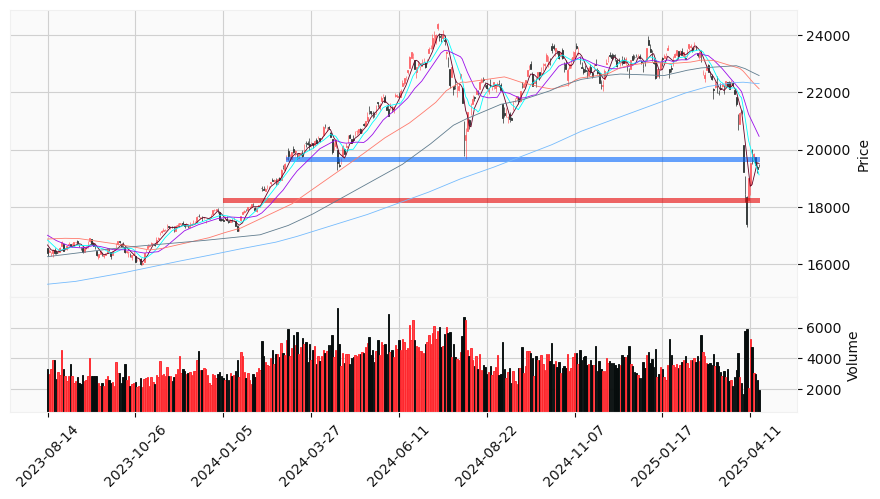

In [7]:
### 基準：股票老師所繪製的線條 ###

# 設定K線格式
mc = mpf.make_marketcolors(up='xkcd:light red', down='xkcd:almost black', inherit=True)
s  = mpf.make_mpf_style(base_mpf_style='yahoo', marketcolors=mc)

# 設定支撐線與壓力線
support_line_start_date    = '2024-01-05'
support_line_end_date      = df_k_line.iloc[-1].name.strftime("%Y-%m-%d")
support_price              = df_k_line.loc['2025-04-10']['Low']
resistance_line_start_date = '2024-03-07'
resistance_line_end_date   = support_line_end_date
resistance_price           = df_k_line.loc['2024-08-06']['Low']
seq_of_seq_of_points=[
    [(support_line_start_date,support_price),(support_line_end_date,support_price)],
    [(resistance_line_start_date,resistance_price),(resistance_line_end_date,resistance_price)]
]
print('支撐線指數 ＝ {:.2f} ， 壓力線指數 ＝ {:.2f}'.format(support_price,resistance_price))

# 設定移動平均線
added_plots={
    "SMA5": mpf.make_addplot(df_sma['SMA5'],width=0.6,color='xkcd:maroon'),
    "SMA10": mpf.make_addplot(df_sma['SMA10'],width=0.6,color='xkcd:cyan'),
    "SMA20": mpf.make_addplot(df_sma['SMA20'],width=0.6,color='xkcd:violet'),
    "SMA60": mpf.make_addplot(df_sma['SMA60'],width=0.6,color='xkcd:salmon'),
    "SMA120": mpf.make_addplot(df_sma['SMA120'],width=0.6,color='xkcd:blue grey'),
    "SMA240": mpf.make_addplot(df_sma['SMA240'],width=0.6,color='xkcd:sky blue')
            }

# 繪製K線圖
kwargs = dict(type='candle', style=s, figratio=(19,10), addplot=list(added_plots.values()), alines=dict(alines=seq_of_seq_of_points, linewidths=2.2, colors=('xkcd:red','xkcd:bright blue'), alpha=0.6), volume=True, datetime_format='%Y-%m-%d')
mpf.plot(df_k_line,**kwargs)

支撐線指數 ＝ 18337.44 ， 壓力線指數 ＝ 19686.68


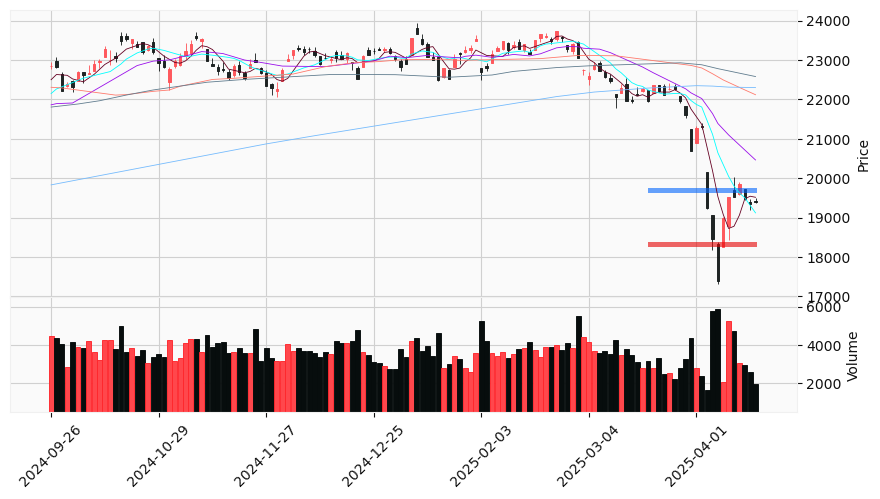

In [8]:
### 基準：股票老師所繪製的線條 ###

# 設定區間價格
range_prices = df_k_line['2024-09-26':]
range_sma    = df_sma['2024-09-26':]

# 設定K線格式
mc = mpf.make_marketcolors(up='xkcd:light red', down='xkcd:almost black', inherit=True)
s  = mpf.make_mpf_style(base_mpf_style='yahoo', marketcolors=mc)

# 設定支撐線與壓力線
support_line_start_date    = '2025-03-19'
support_line_end_date      = range_prices.iloc[-1].name.strftime("%Y-%m-%d")
support_price              = range_prices.loc['2025-04-09']['Open']
resistance_line_start_date = support_line_start_date
resistance_line_end_date   = support_line_end_date
resistance_price           = range_prices.loc['2025-04-14']['Open']
seq_of_seq_of_points=[
    [(support_line_start_date,support_price),(support_line_end_date,support_price)],
    [(resistance_line_start_date,resistance_price),(resistance_line_end_date,resistance_price)]
]
print('支撐線指數 ＝ {:.2f} ， 壓力線指數 ＝ {:.2f}'.format(support_price,resistance_price))

# 設定移動平均線
added_plots={
    "SMA5": mpf.make_addplot(range_sma['SMA5'],width=0.6,color='xkcd:maroon'),
    "SMA10": mpf.make_addplot(range_sma['SMA10'],width=0.6,color='xkcd:cyan'),
    "SMA20": mpf.make_addplot(range_sma['SMA20'],width=0.6,color='xkcd:violet'),
    "SMA60": mpf.make_addplot(range_sma['SMA60'],width=0.6,color='xkcd:salmon'),
    "SMA120": mpf.make_addplot(range_sma['SMA120'],width=0.6,color='xkcd:blue grey'),
    "SMA240": mpf.make_addplot(range_sma['SMA240'],width=0.6,color='xkcd:sky blue')
            }

# 繪製K線圖
kwargs = dict(type='candle', style=s, figratio=(19,10), addplot=list(added_plots.values()), alines=dict(alines=seq_of_seq_of_points, linewidths=2.2, colors=('xkcd:red','xkcd:bright blue'), alpha=0.6), volume=True, datetime_format='%Y-%m-%d')
mpf.plot(range_prices,**kwargs)

支撐線指數 ＝ 17161.79 ， 壓力線指數 ＝ 19830.88


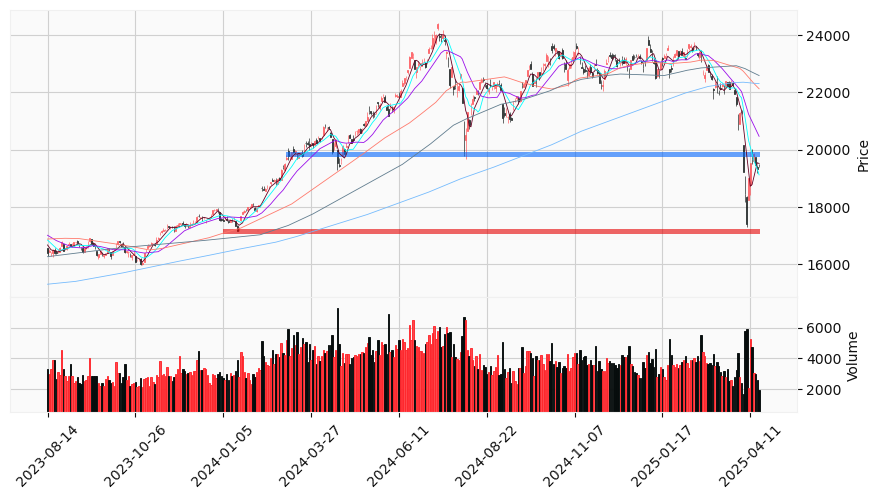

In [9]:
### 繪製壓力與支撐線 ###

# 設定K線格式
mc = mpf.make_marketcolors(up='xkcd:light red', down='xkcd:almost black', inherit=True)
s  = mpf.make_mpf_style(base_mpf_style='yahoo', marketcolors=mc)

# 設定支撐線與壓力線
support_line_start_date = '2024-01-05'
support_line_end_date   = df_k_line.iloc[-1].name.strftime("%Y-%m-%d")
support_price           = df_k_line.loc['2024-01-17']['Close']
resistance_line_start_date = '2024-03-07'
resistance_line_end_date   = df_k_line.iloc[-1].name.strftime("%Y-%m-%d")
resistance_price           = df_k_line.loc['2024-08-05']['Close']
seq_of_seq_of_points=[
    [(support_line_start_date,support_price),(support_line_end_date,support_price)],
    [(resistance_line_start_date,resistance_price),(resistance_line_end_date,resistance_price)]
]
print('支撐線指數 ＝ {:.2f} ， 壓力線指數 ＝ {:.2f}'.format(support_price,resistance_price))

# 設定移動平均線
added_plots={
    "SMA5": mpf.make_addplot(df_sma['SMA5'],width=0.6,color='xkcd:maroon'),
    "SMA10": mpf.make_addplot(df_sma['SMA10'],width=0.6,color='xkcd:cyan'),
    "SMA20": mpf.make_addplot(df_sma['SMA20'],width=0.6,color='xkcd:violet'),
    "SMA60": mpf.make_addplot(df_sma['SMA60'],width=0.6,color='xkcd:salmon'),
    "SMA120": mpf.make_addplot(df_sma['SMA120'],width=0.6,color='xkcd:blue grey'),
    "SMA240": mpf.make_addplot(df_sma['SMA240'],width=0.6,color='xkcd:sky blue')
            }

# 繪製K線圖
kwargs = dict(type='candle', style=s, figratio=(19,10), addplot=list(added_plots.values()), alines=dict(alines=seq_of_seq_of_points, linewidths=2.2, colors=('xkcd:red','xkcd:bright blue'), alpha=0.6), volume=True, datetime_format='%Y-%m-%d')
mpf.plot(df_k_line,**kwargs)

In [10]:
# 建立「股票技術型態識別」物件
chart_pattern = myutils.StockChartPatterns(df_k_line,debug=True)

ＤＥＢＵＧ ： 轉折點引數列表 ＝ [{'mode': 'open_close', 'order': 25}]
＃＃＃ 雙重頂 ＃＃＃
☆ 轉折點參數 ＝ {'mode': 'open_close', 'order': 25} 
★ 型態資訊 ＝ 
                 Date     Price Type
DateIndex                          
53        2023-10-31  16001.27   LO
222       2024-07-11  24390.03   HI
237       2024-08-05  19830.88   LO
287       2024-10-18  23620.57   HI 
◆ 型態最後一個轉折點離價格資料距離 ＝ 118 


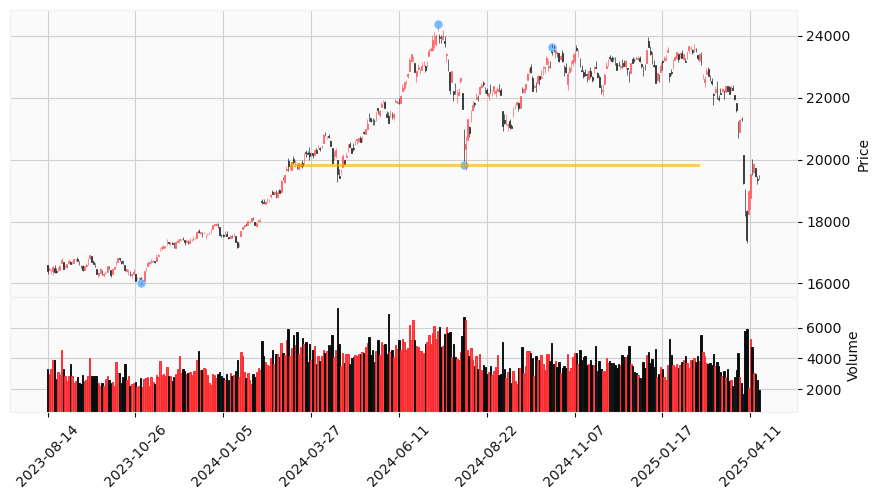

＃＃＃ 上升楔型 ＃＃＃
☆ 轉折點參數 ＝ {'mode': 'open_close', 'order': 25} 
★ 型態資訊 ＝ 
                 Date     Price Type
DateIndex                          
237       2024-08-05  19830.88   LO
287       2024-10-18  23620.57   HI
316       2024-11-29  22202.28   LO
342       2025-01-07  23824.72   HI 
◆ 型態最後一個轉折點離價格資料距離 ＝ 63 


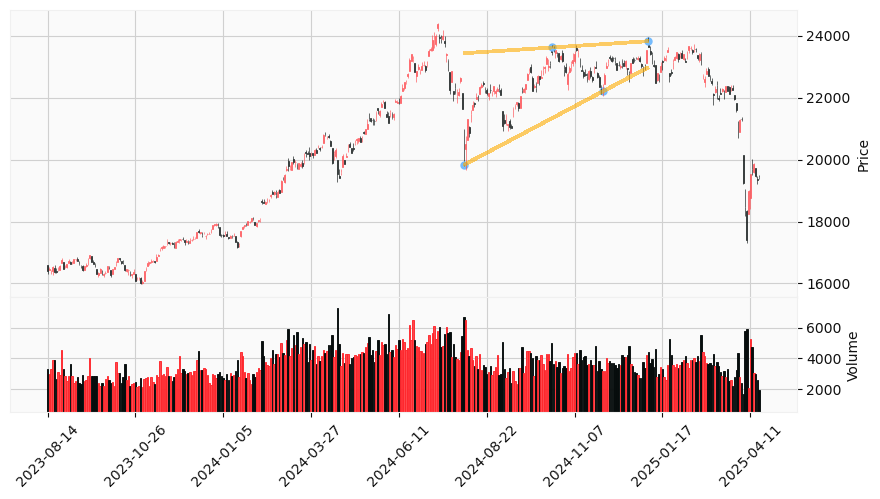

＃＃＃ 矩形 ＃＃＃
☆ 轉折點參數 ＝ {'mode': 'open_close', 'order': 25} 
★ 型態資訊 ＝ 
                 Date     Price Type
DateIndex                          
287       2024-10-18  23620.57   HI
316       2024-11-29  22202.28   LO
342       2025-01-07  23824.72   HI
346       2025-01-13  22488.33   LO 
◆ 型態最後一個轉折點離價格資料距離 ＝ 59 


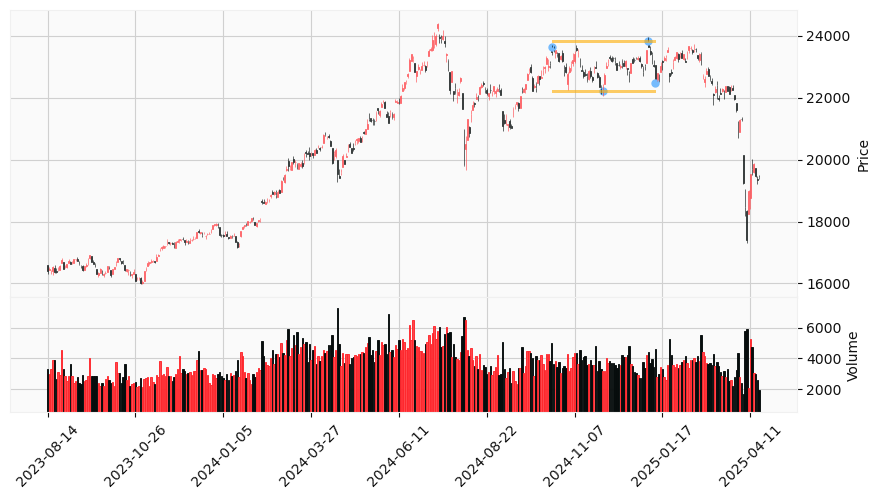

＃＃＃ 看漲三角旗形 ＃＃＃
☆ 轉折點參數 ＝ {'mode': 'open_close', 'order': 25} 
★ 型態資訊 ＝ 
                 Date     Price Type
DateIndex                          
53        2023-10-31  16001.27   LO
222       2024-07-11  24390.03   HI
237       2024-08-05  19830.88   LO
287       2024-10-18  23620.57   HI
316       2024-11-29  22202.28   LO 
◆ 型態最後一個轉折點離價格資料距離 ＝ 89 


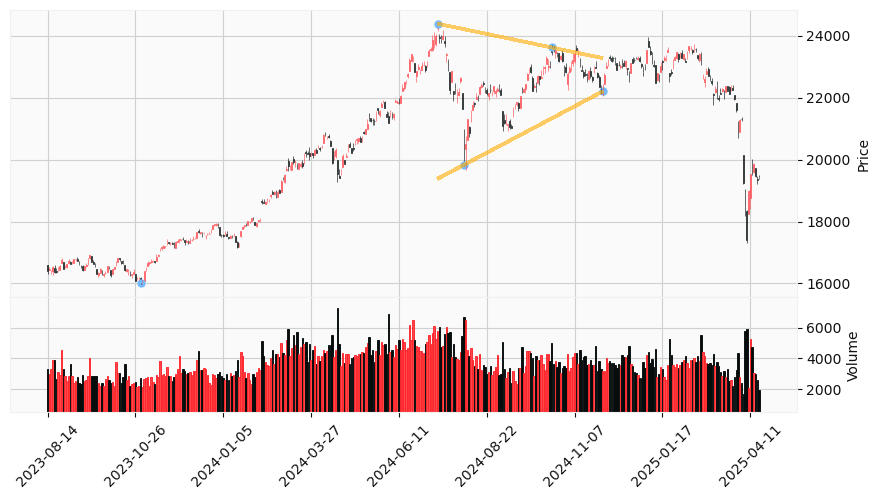

＃＃＃ 三重頂 ＃＃＃
☆ 轉折點參數 ＝ {'mode': 'open_close', 'order': 25} 
★ 型態資訊 ＝ 
                 Date     Price Type
DateIndex                          
237       2024-08-05  19830.88   LO
287       2024-10-18  23620.57   HI
316       2024-11-29  22202.28   LO
342       2025-01-07  23824.72   HI
346       2025-01-13  22488.33   LO
368       2025-02-21  23730.25   HI 
◆ 型態最後一個轉折點離價格資料距離 ＝ 37 


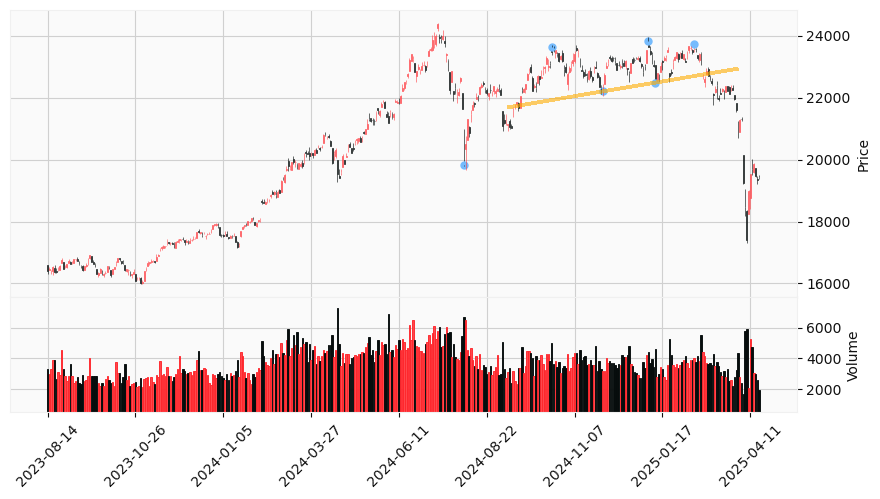

In [11]:
# 進行型態識別
patterns = chart_pattern.Recognition(max_bars = 360,turning_point_args={'mode':'open_close', 'order':25})
patterns_visualization(df_k_line,patterns)

型態類型 ＝ 頭肩頂 ， 型態開始日期 ＝ 2024-06-01 ， 型態結束日期 ＝ 2024-12-01 


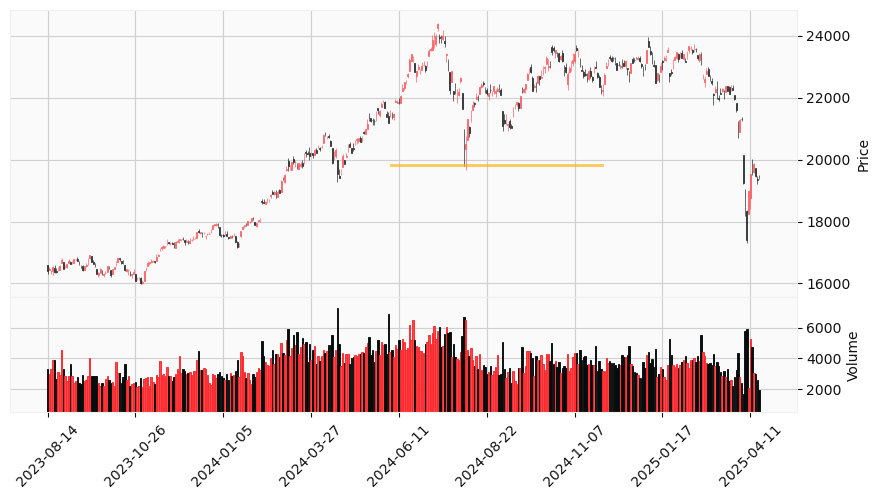

In [12]:
# 進行型態識別(GPT-4o版)
patterns = chart_pattern.RecognitionUsingGPT4o()
gpt4o_patterns_visualization(df_k_line,patterns)